# Notebook 06 — GradCAM Explainability

## What This Notebook Does
So far we've built models that predict defect types with ~96% accuracy.
But accuracy alone doesn't tell us **why** the model made a decision.

This notebook adds **GradCAM** (Gradient-weighted Class Activation Mapping) —
a technique that highlights which parts of the wafer map the model focused on
when making its prediction.

## Why This Matters
- A semiconductor engineer can verify the model is looking at the **right region**
- If the model predicts 'Edge-Ring' but GradCAM lights up the center — something is wrong
- Makes the model trustworthy enough to use in a real factory setting
- Strong portfolio differentiator — most notebooks never go beyond accuracy metrics

## How GradCAM Works (Plain English)
During a forward pass, a CNN produces feature maps — grids of activations at each layer.
GradCAM asks: 'which neurons in the final convolutional layer were most important
for predicting this specific class?'

It does this by computing gradients (how much each neuron influenced the final prediction),
averaging them into weights, and multiplying those weights by the feature maps.
The result is a heatmap the same shape as the wafer — bright = model paid attention here.

## Model Used
We use `best_focal_loss.pt` — the ResNet18 with focal loss that achieved:
- Test Accuracy: 96.67%
- Macro F1: 0.86 (best across all experiments)

---
## Cell 1 — Imports

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import pickle
import cv2                          # For resizing the heatmap to match wafer size
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


---
## Cell 2 — Configuration
All paths and settings in one place — easy to change if your folder structure differs.

In [7]:
# ── Paths ────────────────────────────────────────────────────────────────────
MODEL_PATH        = '../data/processed/best_focal.pt'   # Best model from notebook 04
LABEL_ENCODER_PATH = '../data/processed/label_encoder.pkl'   # Saved in notebook 02
TEST_DATA_PATH    = '../data/processed/test.pkl'             # Held-out test set
OUTPUT_DIR        = '../data/processed/'                     # Where to save output images

# ── Model settings ────────────────────────────────────────────────────────────
IMAGE_SIZE   = 64        # Must match what was used during training
NUM_CLASSES  = 9         # Center, Donut, Edge-Loc, Edge-Ring, Loc, Near-full, Random, Scratch, none
BATCH_SIZE   = 1         # GradCAM is run one sample at a time

# ── Device ────────────────────────────────────────────────────────────────────
# MPS = Apple Silicon GPU, falls back to CPU if not available
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: mps


---
## Cell 3 — Load Label Encoder & Define Class Names
The label encoder maps integers back to human-readable class names.
We saved it in notebook 02 — loading it here keeps the mapping consistent.

In [8]:
# Load the label encoder that was fitted in notebook 02
with open(LABEL_ENCODER_PATH, 'rb') as f:
    le = pickle.load(f)

# le.classes_ gives ['Center', 'Donut', 'Edge-Loc', ...] in sorted order
CLASS_NAMES = list(le.classes_)

print('Class mapping (index → name):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i}: {name}')

Class mapping (index → name):
  0: Center
  1: Donut
  2: Edge-Loc
  3: Edge-Ring
  4: Loc
  5: Near-full
  6: Random
  7: Scratch
  8: none


---
## Cell 4 — Rebuild the Dataset Class
We need the same WaferDataset class from notebook 03 to load test samples.
This must be identical to how data was loaded during training.

In [9]:
class WaferDataset(Dataset):
    """
    Converts raw wafer maps (2D numpy arrays of 0/1/2) into
    3-channel float tensors that ResNet18 can process.
    
    The conversion pipeline:
      Raw array (variable size, values 0/1/2)
      → Resize to IMAGE_SIZE × IMAGE_SIZE
      → Normalize to [0, 1] by dividing by 2
      → Repeat to 3 channels (ResNet expects RGB format)
      → Return as torch.FloatTensor of shape (3, 64, 64)
    """
    
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wafer = row['waferMap']              # Raw 2D numpy array (0, 1, or 2)
        label = int(row['label_encoded'])    # Integer class label
        
        # Resize to fixed size — wafers vary from 18×13 to 212×204 in raw data
        # cv2.resize expects (width, height) so we pass (IMAGE_SIZE, IMAGE_SIZE)
        wafer_resized = cv2.resize(
            wafer.astype(np.float32),
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_NEAREST  # Nearest-neighbor preserves 0/1/2 values
        )
        
        # Normalize: 0→0.0, 1→0.5, 2→1.0
        # Neural networks work best with values in [0, 1]
        wafer_norm = wafer_resized / 2.0
        
        # Convert to tensor shape (1, 64, 64), then repeat to (3, 64, 64)
        # ResNet18 expects 3-channel input (designed for RGB images)
        tensor = torch.FloatTensor(wafer_norm).unsqueeze(0)  # (1, 64, 64)
        tensor = tensor.repeat(3, 1, 1)                       # (3, 64, 64)
        
        return tensor, label


# Load test set and wrap in dataset
test_df      = pd.read_pickle(TEST_DATA_PATH)
test_dataset = WaferDataset(test_df)

print(f'Test set loaded: {len(test_dataset):,} samples')
print(f'Class distribution in test set:')
print(test_df['failureType'].value_counts())

Test set loaded: 17,295 samples
Class distribution in test set:
failureType
none         14743
Edge-Ring      968
Edge-Loc       519
Center         430
Loc            360
Scratch        119
Random          86
Donut           55
Near-full       15
Name: count, dtype: int64


---
## Cell 5 — Load the Trained Model
We rebuild the same ResNet18 architecture and load the saved weights.
The architecture must exactly match what was saved — same number of classes, same final layer.

In [10]:
import os

# ── Step 1: See what model files actually exist ────────────────────────────────
processed_dir = '../data/processed/'
pt_files = [f for f in os.listdir(processed_dir) if f.endswith('.pt')]

print('Model files found in data/processed/:')
for f in sorted(pt_files):
    print(f'  {f}')

Model files found in data/processed/:
  best_focal.pt
  best_resnet18.pt
  best_sqrt_weights.pt
  best_vit.pt
  checkpoint_epoch10.pt
  checkpoint_epoch15.pt
  checkpoint_epoch20.pt
  checkpoint_epoch5.pt
  class_weights.pt
  focal_checkpoint_epoch10.pt
  focal_checkpoint_epoch15.pt
  focal_checkpoint_epoch20.pt
  focal_checkpoint_epoch5.pt
  sqrt_checkpoint_epoch10.pt
  sqrt_checkpoint_epoch15.pt
  sqrt_checkpoint_epoch20.pt
  sqrt_checkpoint_epoch5.pt
  vit_checkpoint_epoch10.pt
  vit_checkpoint_epoch15.pt
  vit_checkpoint_epoch20.pt
  vit_checkpoint_epoch5.pt


In [11]:
def build_model(num_classes):
    """
    Rebuilds ResNet18 with our custom final layer.
    Must be identical to how the model was defined in notebook 04.
    
    ResNet18 originally outputs 1000 classes (ImageNet).
    We replaced model.fc with a linear layer outputting num_classes.
    """
    model = models.resnet18(weights=None)   # weights=None since we load our own
    
    # Replace the final fully-connected layer
    # model.fc originally: Linear(512, 1000)
    # Our version:         Linear(512, 9)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model


# Build the architecture
model = build_model(NUM_CLASSES)

# Load saved weights into the model
# map_location ensures it loads on the correct device (MPS/CPU/CUDA)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)

# Move model to device
model = model.to(device)

# Set to evaluation mode — disables dropout and batch norm updates
# Always do this before inference, never before training
model.eval()

print(f'Model loaded from: {MODEL_PATH}')
print(f'Model is on: {next(model.parameters()).device}')

Model loaded from: ../data/processed/best_focal.pt
Model is on: mps:0


---
## Cell 6 — GradCAM Implementation

### How GradCAM Works Step by Step

```
Input wafer
    ↓
Forward pass through ResNet18
    ↓
Final conv layer produces feature maps  ← we hook into this layer
    shape: (512 channels, 2, 2) for 64×64 input
    ↓
Global Average Pooling + FC layer → class scores
    ↓
We pick the target class score
    ↓
Backward pass: compute gradient of that score w.r.t. feature maps
    shape: (512 channels, 2, 2) — same as feature maps
    ↓
Average gradients across spatial dims → 512 weights (one per channel)
    ↓
Weighted sum of feature maps using those weights
    ↓
ReLU (only keep positive activations — negative = suppresses class)
    ↓
Resize from (2×2) back to (64×64) using interpolation
    ↓
Heatmap showing where the model looked
```

In [16]:
class GradCAM:
    """
    GradCAM extracts a spatial heatmap showing which regions
    of the input the model focused on for a given prediction.
    
    It uses PyTorch 'hooks' — functions that run automatically
    at specific points during forward and backward passes.
    """
    
    def __init__(self, model, target_layer):
        """
        Args:
            model:        The trained ResNet18
            target_layer: Which layer to hook into
                          For ResNet18, 'layer4' is the last conv block
                          — it has the richest high-level features
        """
        self.model        = model
        self.target_layer = target_layer
        
        # These will be populated during forward/backward passes
        self.feature_maps = None   # Activations from the target layer
        self.gradients    = None   # Gradients flowing back through target layer
        
        # Register hooks — these are callbacks PyTorch calls automatically
        self._register_hooks()
    
    def _register_hooks(self):
        """
        Hooks let us 'intercept' activations and gradients
        at any layer without modifying the model itself.
        """
        
        # Forward hook: captures the output (feature maps) of target_layer
        def save_feature_maps(module, input, output):
            # output shape: (batch, 512, H, W)
            # We detach to prevent the saved tensor from affecting gradients
            self.feature_maps = output.detach()
        
        # Backward hook: captures gradients flowing INTO target_layer
        def save_gradients(module, grad_input, grad_output):
            # grad_output[0] shape: (batch, 512, H, W)
            self.gradients = grad_output[0].detach()
        
        # Register both hooks on the target layer
        self.target_layer.register_forward_hook(save_feature_maps)
        self.target_layer.register_full_backward_hook(save_gradients)
    
    def generate(self, input_tensor, target_class=None):
        """
        Generate a GradCAM heatmap for the given input.
        
        Args:
            input_tensor: Wafer map tensor, shape (1, 3, 64, 64)
            target_class: Which class to explain. If None, uses predicted class.
        
        Returns:
            heatmap:    numpy array (64, 64), values in [0, 1]
            pred_class: integer index of predicted class
            pred_conf:  confidence (0-1) of predicted class
        """
        
        # ── Step 1: Forward pass ──────────────────────────────────────────────
        # Enable gradient computation (model.eval() disables it by default)
        input_tensor = input_tensor.to(device)
        input_tensor.requires_grad_(True)
        
        # Forward pass — also triggers our forward hook to capture feature_maps
        output = self.model(input_tensor)   # shape: (1, 9)
        
        # Convert raw scores to probabilities using softmax
        probs = torch.softmax(output, dim=1)
        
        # Determine which class to explain
        pred_class = output.argmax(dim=1).item()
        pred_conf  = probs[0, pred_class].item()
        
        if target_class is None:
            target_class = pred_class   # Explain the predicted class
        
        # ── Step 2: Backward pass ─────────────────────────────────────────────
        # Zero any existing gradients
        self.model.zero_grad()
        
        # We want gradients of the target class score only
        # So we zero out all other class scores before backpropagating
        one_hot = torch.zeros_like(output)        # shape: (1, 9), all zeros
        one_hot[0, target_class] = 1.0            # Set target class to 1
        
        # Backward pass — triggers our backward hook to capture gradients
        output.backward(gradient=one_hot)
        
        # ── Step 3: Compute weights ───────────────────────────────────────────
        # Gradients shape: (1, 512, H, W)
        # Average over spatial dimensions (H, W) → one weight per channel
        # This gives us importance of each feature map channel
        weights = self.gradients.mean(dim=[2, 3])   # shape: (1, 512)
        
        # ── Step 4: Weighted combination of feature maps ──────────────────────
        # feature_maps shape: (1, 512, H, W)
        # weights shape:      (1, 512)
        # 
        # For each of 512 channels: multiply the feature map by its weight
        # Then sum across all 512 channels → one spatial heatmap
        feature_maps = self.feature_maps[0]   # shape: (512, H, W)
        weights_     = weights[0]             # shape: (512,)
        
        # Weighted sum: cam shape = (H, W)
        cam = torch.zeros(feature_maps.shape[1:], device=feature_maps.device)
        for i, w in enumerate(weights_):
            cam += w * feature_maps[i]        # Each channel scaled by its importance
        
        # ── Step 5: Post-process ──────────────────────────────────────────────
        # ReLU: keep only positive values
        # Negative activations = regions that suppress this class (not what we want)
        cam = torch.relu(cam)
        
        # Convert to numpy and resize to match input image size (64×64)
        cam_np = cam.cpu().numpy()
        cam_resized = cv2.resize(cam_np, (IMAGE_SIZE, IMAGE_SIZE))
        
        # Normalize to [0, 1] for visualization
        if cam_resized.max() > cam_resized.min():   # Avoid division by zero
            cam_resized = (cam_resized - cam_resized.min()) / \
                          (cam_resized.max() - cam_resized.min())
        
        return cam_resized, pred_class, pred_conf


# Attach GradCAM to the final convolutional block of ResNet18
# ResNet18 structure: layer1 → layer2 → layer3 → layer4 → avgpool → fc
# layer4 has the highest-level features — best for spatial attribution
gradcam = GradCAM(model, target_layer=model.layer3)

print('GradCAM initialized on model.layer3')

GradCAM initialized on model.layer3


---
## Cell 7 — Visualization Helper
This function overlays the GradCAM heatmap on top of the original wafer map.
It also shows the confidence score and whether the prediction was correct.

In [17]:
def visualize_gradcam(ax_wafer, ax_cam, ax_overlay,
                      wafer_tensor, heatmap, pred_class, true_class, confidence):
    """
    Draws three panels for one sample:
      Panel 1: Raw wafer map
      Panel 2: GradCAM heatmap (hot = model focused here)
      Panel 3: Wafer + heatmap overlaid
    
    Args:
        ax_wafer, ax_cam, ax_overlay: matplotlib axes for each panel
        wafer_tensor:  (3, 64, 64) tensor — we use channel 0 for visualization
        heatmap:       (64, 64) numpy array in [0, 1]
        pred_class:    integer index of predicted class
        true_class:    integer index of true class
        confidence:    float in [0, 1]
    """
    
    # Extract single-channel wafer image from tensor
    # tensor shape: (3, 64, 64) — all 3 channels are identical (we repeated channel 0)
    wafer_np = wafer_tensor[0].cpu().numpy()   # shape: (64, 64), values in [0, 1]
    
    # ── Panel 1: Raw wafer map ────────────────────────────────────────────────
    ax_wafer.imshow(wafer_np, cmap='Blues', vmin=0, vmax=1)
    ax_wafer.set_title('Wafer Map', fontsize=9)
    ax_wafer.axis('off')
    
    # ── Panel 2: GradCAM heatmap ──────────────────────────────────────────────
    # 'jet' colormap: blue=low attention, red=high attention
    ax_cam.imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    ax_cam.set_title('GradCAM', fontsize=9)
    ax_cam.axis('off')
    
    # ── Panel 3: Overlay ──────────────────────────────────────────────────────
    # Convert grayscale wafer to RGB so we can blend with the colored heatmap
    wafer_rgb = np.stack([wafer_np] * 3, axis=-1)   # shape: (64, 64, 3)
    
    # Convert heatmap to RGBA using jet colormap
    heatmap_rgba = cm.jet(heatmap)                  # shape: (64, 64, 4), RGBA
    heatmap_rgb  = heatmap_rgba[:, :, :3]           # Drop alpha channel
    
    # Alpha blend: 60% wafer + 40% heatmap
    # This keeps the wafer structure visible while showing the attention
    alpha   = 0.4
    overlay = (1 - alpha) * wafer_rgb + alpha * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)                # Ensure values stay in [0, 1]
    
    ax_overlay.imshow(overlay)
    
    # Title color: green if correct, red if wrong
    correct      = (pred_class == true_class)
    title_color  = '#2ecc71' if correct else '#e74c3c'
    status_emoji = '✓' if correct else '✗'
    
    pred_name = CLASS_NAMES[pred_class]
    ax_overlay.set_title(
        f'{status_emoji} Pred: {pred_name}\n({confidence:.0%} conf)',
        fontsize=9, color=title_color
    )
    ax_overlay.axis('off')


print('Visualization helper defined')

Visualization helper defined


---
## Cell 8 — Main GradCAM Grid: One Sample Per Class

This is the main output — for each of the 8 defect classes (excluding 'none'),
we find a correctly-classified test sample and show:
1. The raw wafer map
2. The GradCAM heatmap
3. The overlay

**What to look for in the output:**
- Edge-Ring → heatmap should glow along the outer boundary
- Center → heatmap should glow in the middle
- Scratch → heatmap should light up along the line direction
- Loc / Edge-Loc → heatmap should focus on the localized blob

If the heatmap focuses on the **wrong region**, that explains misclassifications.

In [18]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Classes to visualize — everything except 'none' (no defect = not interesting)
DEFECT_CLASSES = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                  'Loc', 'Near-full', 'Random', 'Scratch']

# ── Build index: class_name → list of test sample indices ─────────────────────
# We pre-index so we can quickly find samples of each class
class_to_indices = {}
for i, row in test_df.iterrows():
    label = row.get('failureType', None)
    if label in DEFECT_CLASSES:
        if label not in class_to_indices:
            class_to_indices[label] = []
        class_to_indices[label].append(i)

print('Samples per class in test set:')
for cls in DEFECT_CLASSES:
    count = len(class_to_indices.get(cls, []))
    print(f'  {cls:12s}: {count}')

Samples per class in test set:
  Center      : 430
  Donut       : 55
  Edge-Loc    : 519
  Edge-Ring   : 968
  Loc         : 360
  Near-full   : 15
  Random      : 86
  Scratch     : 119


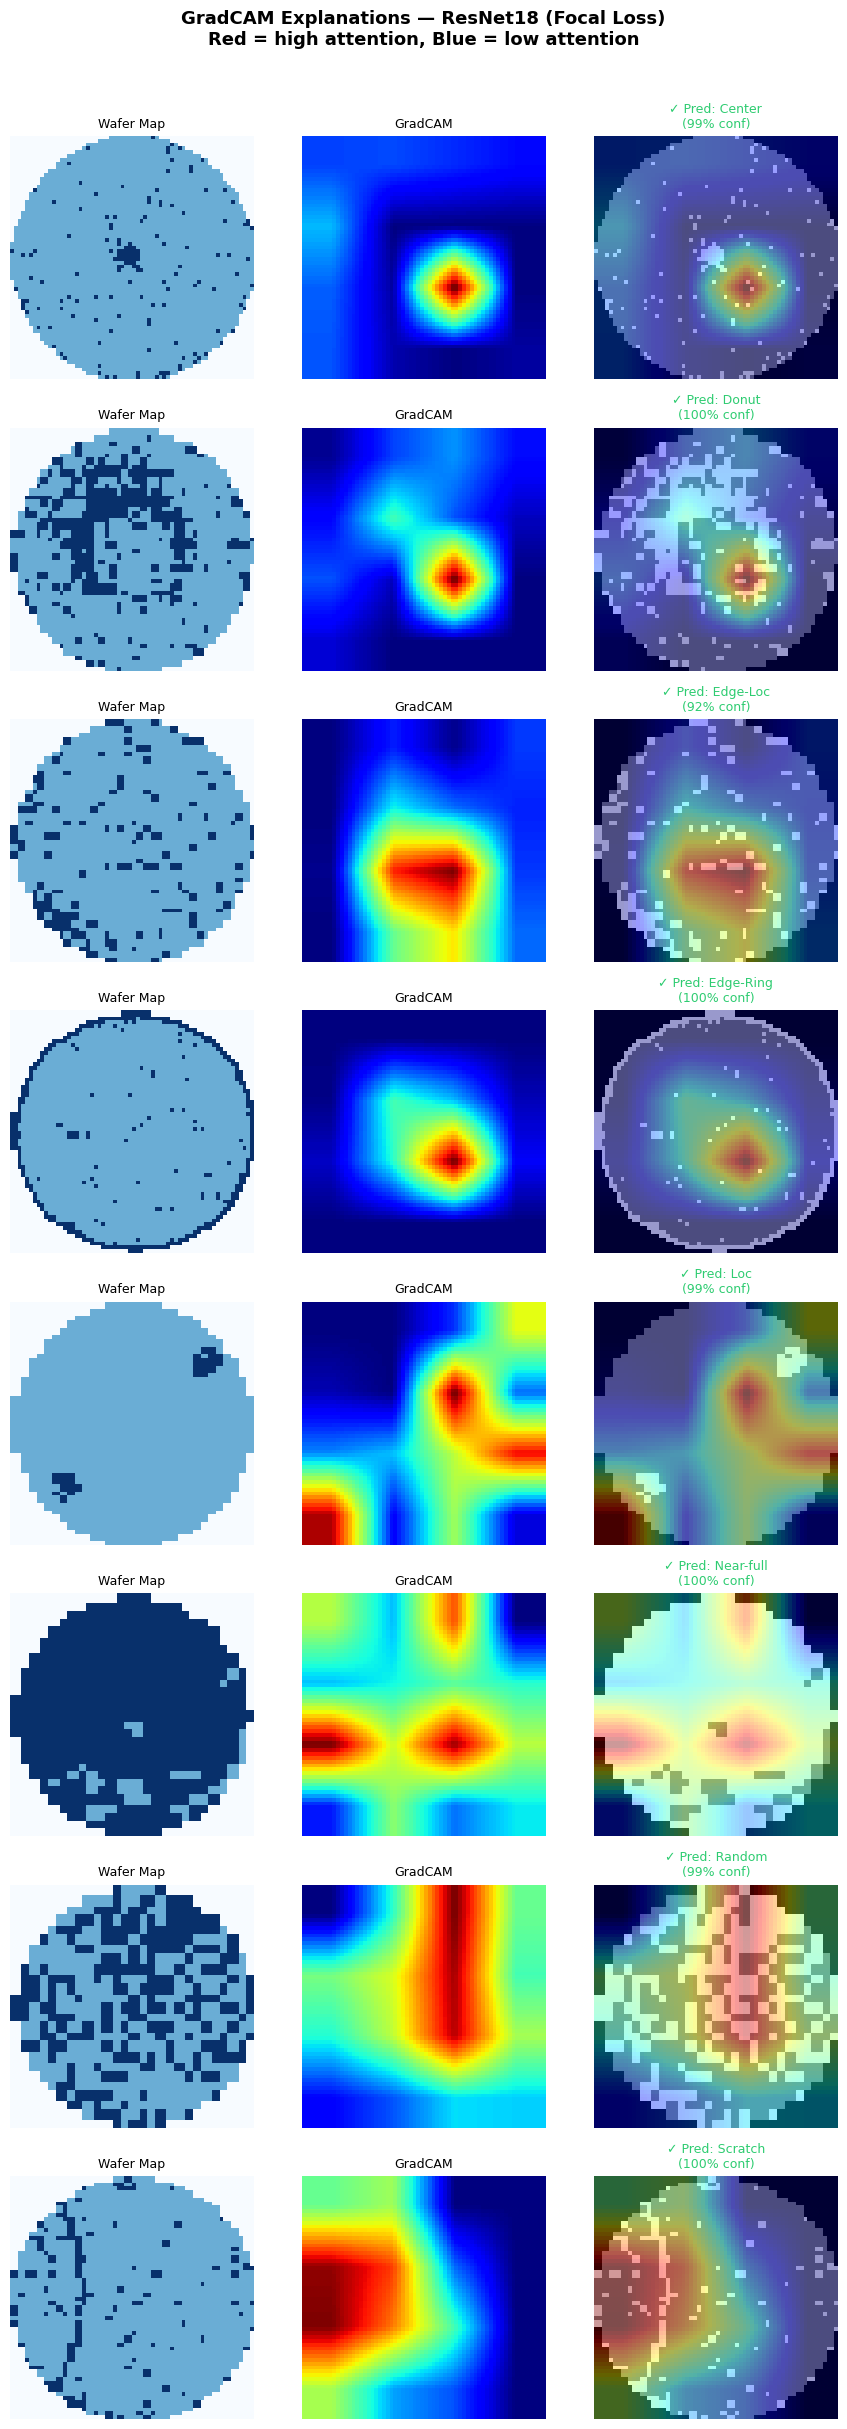


Saved to: ../data/processed/gradcam_all_classes.png


In [19]:
# ── Generate GradCAM for each defect class ────────────────────────────────────

# 8 classes × 3 panels each = 8 rows, 3 columns
fig, axes = plt.subplots(
    nrows=len(DEFECT_CLASSES),
    ncols=3,
    figsize=(9, 3 * len(DEFECT_CLASSES))
)

# Add column headers
for ax, title in zip(axes[0], ['Wafer Map', 'GradCAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)

for row_idx, class_name in enumerate(DEFECT_CLASSES):
    
    # ── Find a good sample for this class ──────────────────────────────────
    sample_found = False
    true_label_idx = CLASS_NAMES.index(class_name)
    
    # Try up to 20 samples from this class looking for a correct prediction
    # (showing correct predictions makes the explanations more meaningful)
    candidates = class_to_indices.get(class_name, [])[:20]
    
    for idx in candidates:
        # Get the sample from the dataset
        # test_df uses original DataFrame index, WaferDataset uses positional index
        positional_idx = test_df.index.get_loc(idx)
        tensor, true_label = test_dataset[positional_idx]
        
        # Add batch dimension: (3, 64, 64) → (1, 3, 64, 64)
        input_batch = tensor.unsqueeze(0)
        
        # Run GradCAM
        heatmap, pred_class, confidence = gradcam.generate(input_batch)
        
        # Prefer correctly-classified samples, but take any if none found
        if pred_class == true_label or not sample_found:
            best_tensor     = tensor
            best_heatmap    = heatmap
            best_pred       = pred_class
            best_conf       = confidence
            best_true       = true_label
            sample_found    = True
            
            if pred_class == true_label:
                break   # Found a correct one — stop searching
    
    if not sample_found:
        # No samples found for this class — draw placeholder
        for ax in axes[row_idx]:
            ax.text(0.5, 0.5, f'No {class_name}\nsamples', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
        continue
    
    # ── Draw the 3 panels for this class ───────────────────────────────────
    ax_wafer, ax_cam, ax_overlay = axes[row_idx]
    
    # Add class label on the left side of the row
    ax_wafer.set_ylabel(class_name, fontsize=10, fontweight='bold',
                        rotation=90, labelpad=8)
    
    visualize_gradcam(
        ax_wafer, ax_cam, ax_overlay,
        best_tensor, best_heatmap,
        best_pred, best_true, best_conf
    )

# ── Final layout and save ──────────────────────────────────────────────────────
fig.suptitle(
    'GradCAM Explanations — ResNet18 (Focal Loss)\n'
    'Red = high attention, Blue = low attention',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()

# Save as high-resolution PNG for README
save_path = f'{OUTPUT_DIR}gradcam_all_classes.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved to: {save_path}')

---
## Cell 9 — GradCAM on Misclassified Samples

This is the most analytically interesting output.
When the model gets it **wrong**, GradCAM often reveals exactly why.

The most common confusions from notebook 05 were:
- Scratch predicted as 'none' (model ignores the scratch line)
- Edge-Loc predicted as Loc (blob in similar position)

Seeing the heatmap on these failures is direct evidence of what the model learned wrong.

In [ ]:
# ── Find misclassified samples ─────────────────────────────────────────────────
# We focus on the two hardest classes from the classification report
HARD_CLASSES = ['Scratch', 'Loc', 'Edge-Loc']

misclassified_samples = []   # List of (tensor, heatmap, pred, true, conf)

for class_name in HARD_CLASSES:
    candidates = class_to_indices.get(class_name, [])[:50]  # Check up to 50 samples
    
    for idx in candidates:
        positional_idx = test_df.index.get_loc(idx)
        tensor, true_label = test_dataset[positional_idx]
        input_batch = tensor.unsqueeze(0)
        
        heatmap, pred_class, confidence = gradcam.generate(input_batch)
        
        # Collect wrong predictions only
        if pred_class != true_label:
            misclassified_samples.append({
                'tensor':     tensor,
                'heatmap':    heatmap,
                'pred':       pred_class,
                'true':       true_label,
                'conf':       confidence,
                'true_name':  CLASS_NAMES[true_label],
                'pred_name':  CLASS_NAMES[pred_class],
            })
            
            # Stop once we have 2 misclassified per class
            class_count = sum(1 for s in misclassified_samples
                              if s['true_name'] == class_name)
            if class_count >= 2:
                break

n_found = len(misclassified_samples)
print(f'Found {n_found} misclassified samples to visualize')
for s in misclassified_samples:
    print(f"  True: {s['true_name']:12s} → Predicted: {s['pred_name']} ({s['conf']:.0%})")

In [ ]:
# ── Plot misclassified samples ─────────────────────────────────────────────────
if n_found == 0:
    print('No misclassifications found in the first 50 samples of each class.')
    print('Your model may be performing very well on these classes now!')
else:
    fig, axes = plt.subplots(
        nrows=n_found,
        ncols=3,
        figsize=(9, 3 * n_found)
    )
    
    # Handle case of only 1 misclassified sample
    if n_found == 1:
        axes = axes.reshape(1, -1)
    
    for ax, title in zip(axes[0], ['Wafer Map', 'GradCAM Heatmap', 'What Went Wrong']):
        ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    
    for row_idx, sample in enumerate(misclassified_samples):
        ax_wafer, ax_cam, ax_overlay = axes[row_idx]
        
        # Row label: shows the true class
        ax_wafer.set_ylabel(f"True:\n{sample['true_name']}",
                            fontsize=9, rotation=90, labelpad=8)
        
        visualize_gradcam(
            ax_wafer, ax_cam, ax_overlay,
            sample['tensor'], sample['heatmap'],
            sample['pred'],   sample['true'], sample['conf']
        )
    
    fig.suptitle(
        'GradCAM on Misclassified Samples\n'
        'Red title = wrong prediction | Heatmap shows what confused the model',
        fontsize=12, fontweight='bold', y=1.01
    )
    
    plt.tight_layout()
    
    save_path = f'{OUTPUT_DIR}gradcam_misclassified.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nSaved to: {save_path}')

---
## Cell 10 — Single Sample Deep Dive

Use this cell to inspect any individual sample interactively.
Change `TARGET_CLASS` and `SAMPLE_INDEX` to explore different cases.

This is useful during presentations — you can pull up any wafer on demand.

In [ ]:
# ── Change these to explore different samples ──────────────────────────────────
TARGET_CLASS  = 'Scratch'   # Any class name from CLASS_NAMES
SAMPLE_INDEX  = 0           # Which sample of that class (0 = first, 1 = second, ...)

# ── Run GradCAM for the specified sample ──────────────────────────────────────
indices   = class_to_indices.get(TARGET_CLASS, [])

if SAMPLE_INDEX >= len(indices):
    print(f'Only {len(indices)} samples of {TARGET_CLASS} in test set.')
else:
    idx            = indices[SAMPLE_INDEX]
    positional_idx = test_df.index.get_loc(idx)
    tensor, true_label = test_dataset[positional_idx]
    
    heatmap, pred_class, confidence = gradcam.generate(tensor.unsqueeze(0))
    
    # ── Large 3-panel plot ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    visualize_gradcam(
        axes[0], axes[1], axes[2],
        tensor, heatmap, pred_class, true_label, confidence
    )
    
    correct = '✓ Correct' if pred_class == true_label else '✗ Wrong'
    fig.suptitle(
        f'{TARGET_CLASS} — Sample {SAMPLE_INDEX}  |  '
        f'Predicted: {CLASS_NAMES[pred_class]} ({confidence:.1%})  |  {correct}',
        fontsize=12, fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()
    
    # ── Print interpretation ──────────────────────────────────────────────────
    print(f'\nInterpretation:')
    print(f'  True class:  {CLASS_NAMES[true_label]}')
    print(f'  Predicted:   {CLASS_NAMES[pred_class]} ({confidence:.1%} confidence)')
    print(f'  GradCAM:     Bright red regions = where model focused its attention')
    print(f'               Check if highlighted area matches the expected defect pattern')

---
## Summary

### What This Notebook Produced
1. **`gradcam_all_classes.png`** — 8×3 grid showing GradCAM for every defect type. Use this in your README.
2. **`gradcam_misclassified.png`** — GradCAM on wrong predictions, explaining model failures.

### Key Takeaways to Note in Your Portfolio
- For well-learned classes (Edge-Ring, Center): heatmap should perfectly match the defect region
- For Scratch: heatmap may scatter or focus on wrong regions — explains the low F1 score
- For Loc vs Edge-Loc confusion: heatmaps likely show similar activation regions

### What Comes Next
- **Notebook 07**: Gradio demo app — upload a wafer, see prediction + GradCAM live
- **Notebook 08 (optional)**: Targeted Scratch augmentation to fix the F1=0.51 problem